# Deep Belief Network (DBN) - PyTorch



Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]



Training RBM Layer 1...
Epoch [1/5] | Loss: -146.5410
Epoch [2/5] | Loss: -177.9301
Epoch [3/5] | Loss: -184.1405
Epoch [4/5] | Loss: -186.6125
Epoch [5/5] | Loss: -187.6881

Weights initialized from RBM successfully!

Fine-tuning DBN...
Epoch [1/10] | Accuracy: 93.00%
Epoch [2/10] | Accuracy: 97.12%
Epoch [3/10] | Accuracy: 98.04%
Epoch [4/10] | Accuracy: 98.61%
Epoch [5/10] | Accuracy: 98.95%
Epoch [6/10] | Accuracy: 99.13%
Epoch [7/10] | Accuracy: 99.32%
Epoch [8/10] | Accuracy: 99.45%
Epoch [9/10] | Accuracy: 99.50%
Epoch [10/10] | Accuracy: 99.61%

Test Accuracy: 97.60%


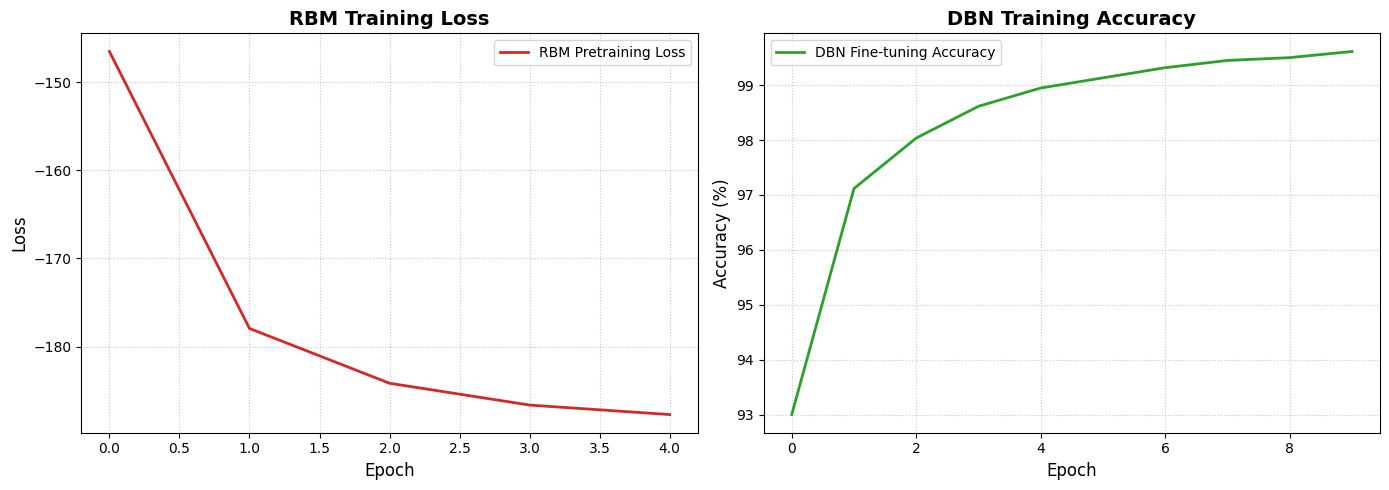

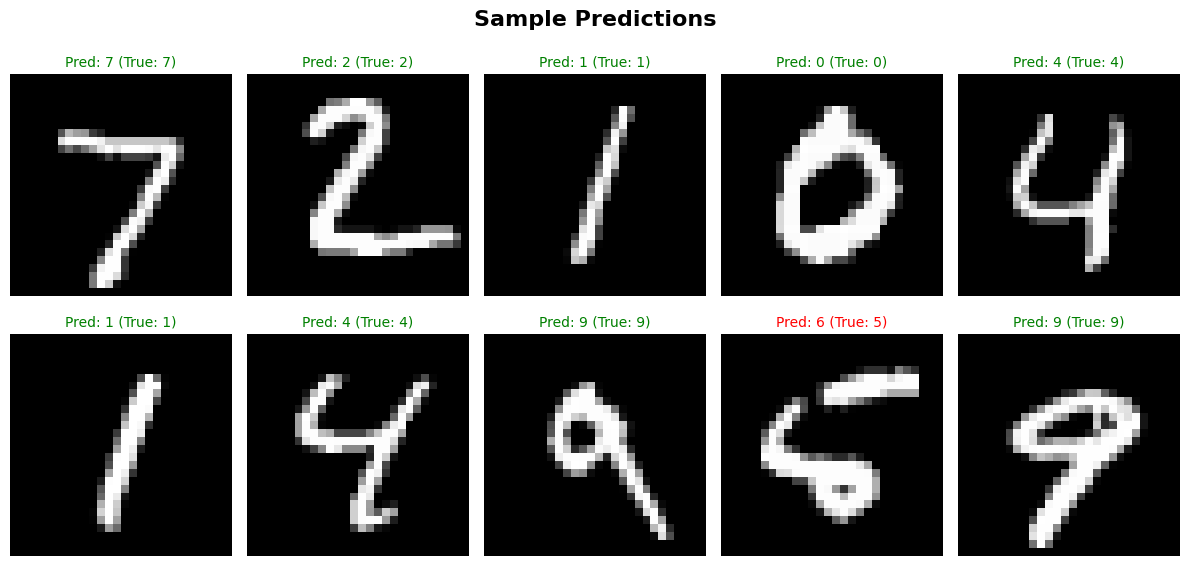

In [1]:
# ============================================================
# Deep Belief Network (DBN) using PyTorch
# RBM + Fine-tuning
# Dataset: MNIST
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Device Configuration
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 2. Load MNIST Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ============================================================
# 3. Restricted Boltzmann Machine (RBM)
# ============================================================
class RBM(nn.Module):
    def __init__(self, visible_units=784, hidden_units=256):
        super(RBM, self).__init__()
        self.visible_units = visible_units
        self.hidden_units = hidden_units

        # Weight matrix
        self.W = nn.Parameter(torch.randn(hidden_units, visible_units) * 0.01)

        # Biases
        self.h_bias = nn.Parameter(torch.zeros(hidden_units))
        self.v_bias = nn.Parameter(torch.zeros(visible_units))

    def sample_hidden(self, v):
        h_prob = torch.sigmoid(torch.matmul(v, self.W.t()) + self.h_bias)
        h_sample = torch.bernoulli(h_prob)
        return h_prob, h_sample

    def sample_visible(self, h):
        v_prob = torch.sigmoid(torch.matmul(h, self.W) + self.v_bias)
        v_sample = torch.bernoulli(v_prob)
        return v_prob, v_sample

    def forward(self, v):
        # Positive phase
        h_prob, h_sample = self.sample_hidden(v)
        # Negative phase
        v_prob, v_sample = self.sample_visible(h_sample)
        h_prob_neg, _ = self.sample_hidden(v_prob)
        return v, v_prob, h_prob, h_prob_neg

    def free_energy(self, v):
        vbias_term = torch.matmul(v, self.v_bias)
        wx_b = torch.matmul(v, self.W.t()) + self.h_bias
        hidden_term = torch.sum(torch.log(1 + torch.exp(wx_b)), dim=1)
        return torch.mean(-hidden_term - vbias_term)

# ============================================================
# 4. Train RBM (Unsupervised Pretraining)
# ============================================================
rbm1 = RBM(visible_units=784, hidden_units=256).to(device)
optimizer_rbm = optim.Adam(rbm1.parameters(), lr=0.001)
epochs_rbm = 5
rbm_losses = []

print("\nTraining RBM Layer 1...")
for epoch in range(epochs_rbm):
    epoch_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.view(-1, 784).to(device)
        v, v_prob, h_prob, h_prob_neg = rbm1(data)

        # Contrastive Divergence Loss approximation using Free Energy
        loss = torch.mean(rbm1.free_energy(v)) - torch.mean(rbm1.free_energy(v_prob))

        optimizer_rbm.zero_grad()
        loss.backward()
        optimizer_rbm.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    rbm_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs_rbm}] | Loss: {avg_loss:.4f}")

# ============================================================
# 5. Deep Belief Network (DBN)
# ============================================================
class DBN(nn.Module):
    def __init__(self, rbm):
        super(DBN, self).__init__()

        # First hidden layer initialized from RBM
        self.fc1 = nn.Linear(784, 256)
        self.fc1.weight.data = rbm.W.data.clone()
        self.fc1.bias.data = rbm.h_bias.data.clone()

        # Additional layers for classification
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

dbn = DBN(rbm1).to(device)
print("\nWeights initialized from RBM successfully!")

# ============================================================
# 6. Fine-Tuning (Supervised Learning)
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer_dbn = optim.Adam(dbn.parameters(), lr=0.001)
epochs_dbn = 10
train_acc_history = []

print("\nFine-tuning DBN...")
for epoch in range(epochs_dbn):
    dbn.train()
    correct, total = 0, 0

    for data, targets in train_loader:
        data = data.view(-1, 784).to(device)
        targets = targets.to(device)

        outputs = dbn(data)
        loss = criterion(outputs, targets)

        optimizer_dbn.zero_grad()
        loss.backward()
        optimizer_dbn.step()

        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    accuracy = 100 * correct / total
    train_acc_history.append(accuracy)
    print(f"Epoch [{epoch+1}/{epochs_dbn}] | Accuracy: {accuracy:.2f}%")

# ============================================================
# 7. Evaluate Model
# ============================================================
dbn.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for data, targets in test_loader:
        data = data.view(-1, 784).to(device)
        targets = targets.to(device)

        outputs = dbn(data)
        _, predicted = torch.max(outputs.data, 1)

        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

# ============================================================
# 8. Visualization
# ============================================================

# --- Plot 1: Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RBM Loss Plot
ax1.plot(rbm_losses, label='RBM Pretraining Loss', color='#d62728', linewidth=2)
ax1.set_title("RBM Training Loss", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.7)

# DBN Accuracy Plot
ax2.plot(train_acc_history, label='DBN Fine-tuning Accuracy', color='#2ca02c', linewidth=2)
ax2.set_title("DBN Training Accuracy", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

# --- Plot 2: Sample Predictions ---
examples = iter(test_loader)
example_data, example_targets = next(examples)
example_data_gpu = example_data.to(device)

with torch.no_grad():
    outputs = dbn(example_data_gpu.view(-1, 784))
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(10):
    img = example_data[i].squeeze()
    axes[i].imshow(img, cmap='gray')

    # Highlight incorrect predictions in red, correct in green
    color = "green" if preds[i].item() == example_targets[i].item() else "red"
    axes[i].set_title(f"Pred: {preds[i].item()} (True: {example_targets[i].item()})", color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle("Sample Predictions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()